# **Assignment** **6**


# **Name: Shantanu Kaute | Roll No. 07 | PRN no. 1252090007

**6.Use the diabetes data set from UCI and Pima Indians Diabetes data set for performing the following: a. Univariate analysis: Frequency, Mean, Median, Mode, Variance, Standard Deviation, Skewness and Kurtosis b. Bivariate analysis: Linear and logistic regression modeling c. Multiple Regression analysis d. Also compare the results of the above analysis for the two data sets.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix

In [2]:
import pandas as pd
df = pd.read_csv("diabetes.csv")
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
from sklearn.datasets import load_diabetes
diabetes = load_diabetes()
sklearn_df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
sklearn_df['target'] = diabetes.target

print("Sklearn Diabetes Shape:", sklearn_df.shape)
sklearn_df.head()

Sklearn Diabetes Shape: (442, 11)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [4]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [5]:
sklearn_df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


In [6]:
sklearn_df.isnull().sum()

,0
age,0
sex,0
bmi,0
bp,0
s1,0
s2,0
s3,0
s4,0
s5,0
s6,0


In [7]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [8]:
def univariate_analysis(df):
    result = pd.DataFrame({
        "Mean": df.mean(),
        "Median": df.median(),
        "Mode": df.mode().iloc[0],
        "Variance": df.var(),
        "Std Dev": df.std(),
        "Skewness": df.skew(),
        "Kurtosis": df.kurt()
    })
    return result
print(univariate_analysis(df))
print(univariate_analysis(sklearn_df))

                                Mean    Median    Mode      Variance  \
Pregnancies                 3.845052    3.0000   1.000     11.354056   
Glucose                   120.894531  117.0000  99.000   1022.248314   
BloodPressure              69.105469   72.0000  70.000    374.647271   
SkinThickness              20.536458   23.0000   0.000    254.473245   
Insulin                    79.799479   30.5000   0.000  13281.180078   
BMI                        31.992578   32.0000  32.000     62.159984   
DiabetesPedigreeFunction    0.471876    0.3725   0.254      0.109779   
Age                        33.240885   29.0000  22.000    138.303046   
Outcome                     0.348958    0.0000   0.000      0.227483   

                             Std Dev  Skewness  Kurtosis  
Pregnancies                 3.369578  0.901674  0.159220  
Glucose                    31.972618  0.173754  0.640780  
BloodPressure              19.355807 -1.843608  5.180157  
SkinThickness              15.952218  0.109

In [9]:
df['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


**Single Linnear Regression**

Linear Regression Results (Sklearn Dataset)
Coefficient: [988.41931249]
Intercept: 151.04202449316014
R2 Score: 0.2803417492440603
MSE: 3884.936720961032
RMSE: 62.32926055201547


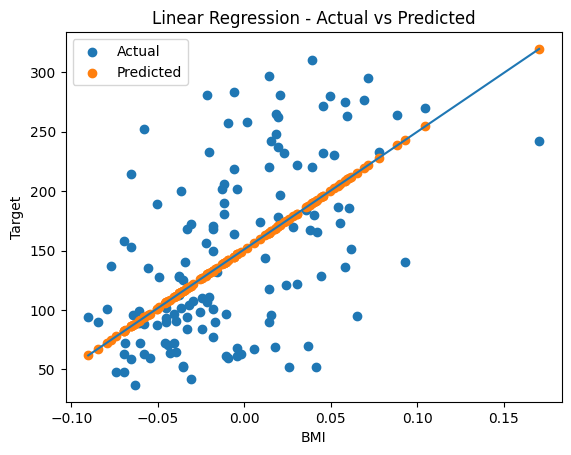

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error


X = sklearn_df[['bmi']]
y = sklearn_df['target']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)


y_pred = lin_reg.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("Linear Regression Results (Sklearn Dataset)")
print("Coefficient:", lin_reg.coef_)
print("Intercept:", lin_reg.intercept_)
print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mse)
print("RMSE:", rmse)


plt.figure()

sorted_index = X_test['bmi'].argsort()
X_test_sorted = X_test.iloc[sorted_index]
y_test_sorted = y_test.iloc[sorted_index]
y_pred_sorted = y_pred[sorted_index]

plt.scatter(X_test_sorted, y_test_sorted, label="Actual")

plt.scatter(X_test_sorted, y_pred_sorted, label="Predicted")

plt.plot(X_test_sorted, y_pred_sorted)

plt.xlabel("BMI")
plt.ylabel("Target")
plt.title("Linear Regression - Actual vs Predicted")
plt.legend()
plt.show()

**MULTIPLE LINEAR REGRESSION**


Multiple Linear Regression Results
R2 Score: 0.4772897164322617
MSE: 2821.750981001311
RMSE: 53.120156070942706


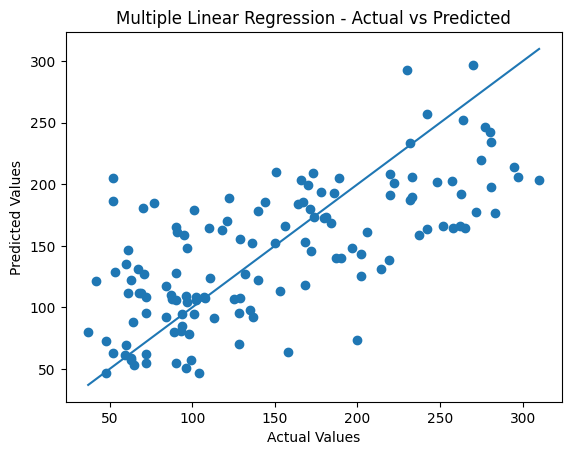

In [11]:
X = sklearn_df.drop("target", axis=1)
y = sklearn_df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

multi_reg = LinearRegression()
multi_reg.fit(X_train, y_train)

y_pred_multi = multi_reg.predict(X_test)

mse_multi = mean_squared_error(y_test, y_pred_multi)
rmse_multi = np.sqrt(mse_multi)

print("\nMultiple Linear Regression Results")
print("R2 Score:", r2_score(y_test, y_pred_multi))
print("MSE:", mse_multi)
print("RMSE:", rmse_multi)

plt.figure()

plt.scatter(y_test, y_pred_multi)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Multiple Linear Regression - Actual vs Predicted")
plt.show()

**SINGLE LOGISTIC REGRESSION**


Single Logistic Regression Results
Accuracy: 0.7229437229437229
Confusion Matrix:
 [[128  23]
 [ 41  39]]


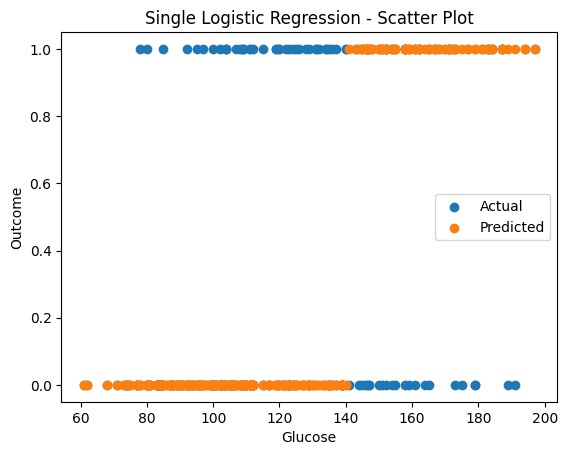

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

X = df[['Glucose']]
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

log_reg_single = LogisticRegression(max_iter=1000)
log_reg_single.fit(X_train, y_train)

y_pred_log_single = log_reg_single.predict(X_test)

print("\nSingle Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_log_single))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log_single))

plt.figure()

plt.scatter(X_test, y_test, label="Actual")
plt.scatter(X_test, y_pred_log_single, label="Predicted")

plt.xlabel("Glucose")
plt.ylabel("Outcome")
plt.title("Single Logistic Regression - Scatter Plot")
plt.legend()
plt.show()

**MULTIPLE LOGISTIC REGRESSION**


Multiple Logistic Regression Results
Accuracy: 0.7359307359307359
Confusion Matrix:
 [[120  31]
 [ 30  50]]


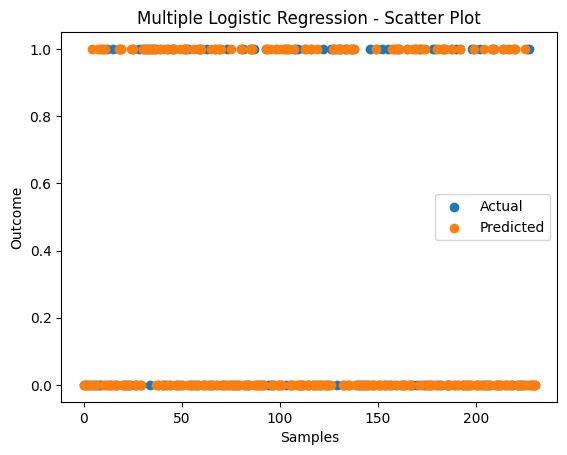

In [13]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

log_reg_multi = LogisticRegression(max_iter=1000)
log_reg_multi.fit(X_train, y_train)

y_pred_log_multi = log_reg_multi.predict(X_test)

print("\nMultiple Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_log_multi))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log_multi))

plt.figure()

plt.scatter(range(len(y_test)), y_test, label="Actual")
plt.scatter(range(len(y_pred_log_multi)), y_pred_log_multi, label="Predicted")

plt.xlabel("Samples")
plt.ylabel("Outcome")
plt.title("Multiple Logistic Regression - Scatter Plot")

plt.legend()
plt.show()

# [**DATASET COMPARISON**](https://)

In [14]:
comparison_info = pd.DataFrame({
    "Dataset": ["diabetes.csv", "Sklearn Diabetes"],
    "Samples": [df.shape[0], sklearn_df.shape[0]],
    "Features": [df.shape[1]-1, sklearn_df.shape[1]-1],
    "Target Type": ["Binary (0/1)", "Continuous"]
})

print(comparison_info)

            Dataset  Samples  Features   Target Type
0      diabetes.csv      768         8  Binary (0/1)
1  Sklearn Diabetes      442        10    Continuous


In [17]:
plt.figure()

plt.scatter(y_test_multi, y_pred_multi, alpha=0.6)

plt.plot([y_test_multi.min(), y_test_multi.max()],
         [y_test_multi.min(), y_test_multi.max()])

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Sklearn Diabetes Dataset (Regression Result)")
plt.show()

NameError: name 'y_test_multi' is not defined

<Figure size 640x480 with 0 Axes>